In [1]:
# 기본 패키지
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 모델링
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
from matplotlib import font_manager, rc

font_location = "C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(fname=font_location).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False


In [2]:
import xml.etree.ElementTree as ET
import pandas as pd

def load_xml_to_df(file):
    tree = ET.parse(file)
    root = tree.getroot()

    rows = []
    for event in root.find("glucose_level").findall("event"):
        ts = event.attrib["ts"]
        value = event.attrib["value"]
        rows.append([ts, float(value)])

    return pd.DataFrame(rows, columns=["timestamp", "glucose"])

# 3명 데이터 불러오기
files = ["570-ws-training.xml", "563-ws-training.xml", "588-ws-training.xml"]
patients = [load_xml_to_df(f) for f in files]

# 확인
for i, df in enumerate(patients):
    print(f"환자 {i+1} 데이터 크기:", df.shape)
    print(df.head(), "\n")


환자 1 데이터 크기: (10982, 2)
             timestamp  glucose
0  07-12-2021 16:29:00    101.0
1  07-12-2021 16:34:00    100.0
2  07-12-2021 16:39:00    100.0
3  07-12-2021 16:44:00     99.0
4  07-12-2021 16:49:00     98.0 

환자 2 데이터 크기: (12124, 2)
             timestamp  glucose
0  13-09-2021 12:33:00    219.0
1  13-09-2021 12:38:00    229.0
2  13-09-2021 12:43:00    224.0
3  13-09-2021 12:48:00    221.0
4  13-09-2021 12:53:00    215.0 

환자 3 데이터 크기: (12640, 2)
             timestamp  glucose
0  30-08-2021 11:53:00    116.0
1  30-08-2021 11:58:00    117.0
2  30-08-2021 12:03:00    119.0
3  30-08-2021 12:08:00    116.0
4  30-08-2021 12:13:00    111.0 



In [3]:
# timestamp를 datetime으로 변환
for i, df in enumerate(patients):
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d-%m-%Y %H:%M:%S")
    df.set_index("timestamp", inplace=True)
    # 5분 단위로 리샘플링
    patients[i] = df.resample("5T").mean().interpolate()


In [4]:
import numpy as np
import pandas as pd

# recent_len=12(60분), horizon=24(120분)
def make_xy_from_df(df, recent_len=12, horizon=24):
    g = df["glucose"].values.astype(float)
    X, y = [], []
    limit = len(g) - (recent_len + horizon)
    for i in range(limit):
        X.append(g[i:i+recent_len])
        y.append(g[i+recent_len+horizon-1])  # 120분 뒤 1포인트
    return np.array(X), np.array(y)

# 환자별 데이터셋 만들기
per_patient = [make_xy_from_df(df, recent_len=12, horizon=24) for df in patients]


In [5]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

lopo_rows = []
for test_idx in range(len(per_patient)):
    # 학습용 X,y (나머지 환자 합치기)
    X_train = np.vstack([per_patient[i][0] for i in range(len(per_patient)) if i != test_idx])
    y_train = np.hstack([per_patient[i][1] for i in range(len(per_patient)) if i != test_idx])
    # 테스트용
    X_test, y_test = per_patient[test_idx]

    model = LGBMRegressor(
        n_estimators=600, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.9, colsample_bytree=0.9,
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds, squared=False)
    lopo_rows.append({"환자": f"환자 {test_idx+1}", "MAE": mae, "RMSE": rmse})

import pandas as pd
lopo_df = pd.DataFrame(lopo_rows)
print("=== LGBM LOPO 결과 (다른 환자로 학습 → 해당 환자 예측) ===")
print(lopo_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2976
[LightGBM] [Info] Number of data points in the train set: 26132, number of used features: 12
[LightGBM] [Info] Start training from score 154.840751
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001634 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3036
[LightGBM] [Info] Number of data points in the train set: 24645, number of used features: 12
[LightGBM] [Info] Start training from score 176.581923
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001723 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3036
[LightGBM] [Info] Number of data points in the train set: 24637, number of used features: 12
[LightGBM] [Info] Start

In [6]:
from sklearn.model_selection import train_test_split

self_rows = []
for i in range(len(per_patient)):
    X, y = per_patient[i]
    # 시간 순서 유지 위해 shuffle=False
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = LGBMRegressor(
        n_estimators=600, learning_rate=0.05, num_leaves=31,
        max_depth=-1, subsample=0.9, colsample_bytree=0.9,
        random_state=42
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae = mean_absolute_error(y_te, preds)
    rmse = mean_squared_error(y_te, preds, squared=False)
    self_rows.append({"환자": f"환자 {i+1}", "MAE": mae, "RMSE": rmse})

self_df = pd.DataFrame(self_rows)
print("\n=== LGBM Self 결과 (자기 데이터 학습 → 자기 예측) ===")
print(self_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000351 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 9260, number of used features: 12
[LightGBM] [Info] Start training from score 187.099622
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000556 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2928
[LightGBM] [Info] Number of data points in the train set: 10449, number of used features: 12
[LightGBM] [Info] Start training from score 141.022155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3012
[LightGBM] [Info] Number of data points in the train set: 10456, number of used features: 12
[LightGBM] [Info] Start 

In [7]:
# 전체로 학습
X_all = np.vstack([per_patient[i][0] for i in range(len(per_patient))])
y_all = np.hstack([per_patient[i][1] for i in range(len(per_patient))])

mix_model = LGBMRegressor(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    max_depth=-1, subsample=0.9, colsample_bytree=0.9,
    random_state=42
)
mix_model.fit(X_all, y_all)

mixed_rows = []
for i in range(len(per_patient)):
    X_te, y_te = per_patient[i]
    preds = mix_model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = mean_squared_error(y_te, preds, squared=False)
    mixed_rows.append({"환자": f"환자 {i+1}", "MAE": mae, "RMSE": rmse})

mixed_df = pd.DataFrame(mixed_rows)
print("\n=== LGBM Mixed 결과 (모든 환자 합쳐 학습 → 환자별 평가) ===")
print(mixed_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3030
[LightGBM] [Info] Number of data points in the train set: 37707, number of used features: 12
[LightGBM] [Info] Start training from score 165.627165

=== LGBM Mixed 결과 (모든 환자 합쳐 학습 → 환자별 평가) ===
     환자        MAE       RMSE
0  환자 1  23.476196  30.777397
1  환자 2  24.968376  32.121760
2  환자 3  23.736988  31.180277


In [8]:
# 전체로 학습
X_all = np.vstack([per_patient[i][0] for i in range(len(per_patient))])
y_all = np.hstack([per_patient[i][1] for i in range(len(per_patient))])

mix_model = LGBMRegressor(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    max_depth=-1, subsample=0.9, colsample_bytree=0.9,
    random_state=42
)
mix_model.fit(X_all, y_all)

mixed_rows = []
for i in range(len(per_patient)):
    X_te, y_te = per_patient[i]
    preds = mix_model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = mean_squared_error(y_te, preds, squared=False)
    mixed_rows.append({"환자": f"환자 {i+1}", "MAE": mae, "RMSE": rmse})

mixed_df = pd.DataFrame(mixed_rows)
print("\n=== LGBM Mixed 결과 (모든 환자 합쳐 학습 → 환자별 평가) ===")
print(mixed_df)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3030
[LightGBM] [Info] Number of data points in the train set: 37707, number of used features: 12
[LightGBM] [Info] Start training from score 165.627165

=== LGBM Mixed 결과 (모든 환자 합쳐 학습 → 환자별 평가) ===
     환자        MAE       RMSE
0  환자 1  23.476196  30.777397
1  환자 2  24.968376  32.121760
2  환자 3  23.736988  31.180277


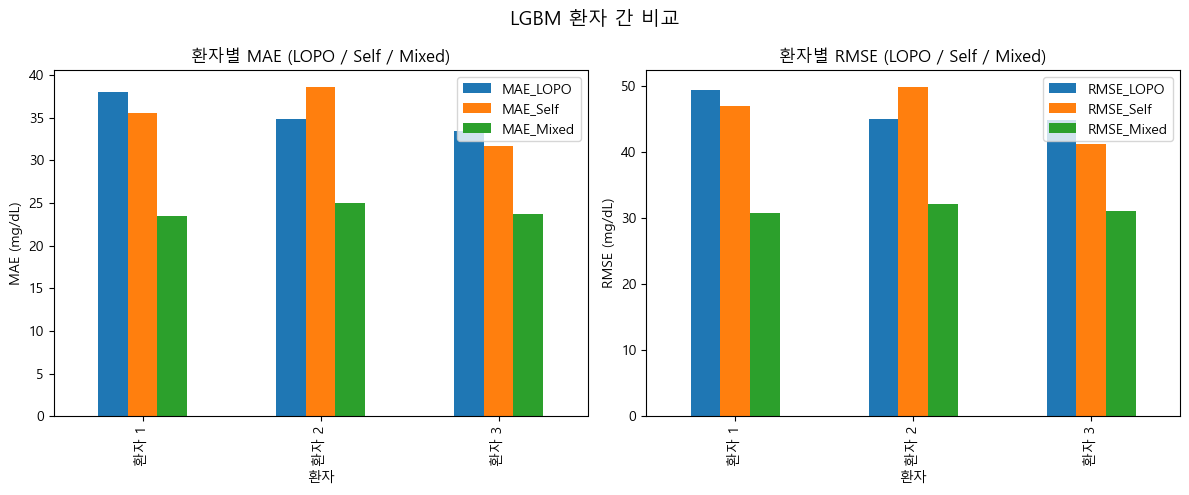

In [9]:
import matplotlib.pyplot as plt

compare = lopo_df.set_index("환자").join(
    self_df.set_index("환자"), lsuffix="_LOPO", rsuffix="_Self"
).join(
    mixed_df.set_index("환자"), rsuffix="_Mixed"
)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# MAE
compare[["MAE_LOPO","MAE_Self","MAE"]].rename(columns={"MAE":"MAE_Mixed"}).plot.bar(ax=axes[0])
axes[0].set_title("환자별 MAE (LOPO / Self / Mixed)")
axes[0].set_ylabel("MAE (mg/dL)")

# RMSE
compare[["RMSE_LOPO","RMSE_Self","RMSE"]].rename(columns={"RMSE":"RMSE_Mixed"}).plot.bar(ax=axes[1])
axes[1].set_title("환자별 RMSE (LOPO / Self / Mixed)")
axes[1].set_ylabel("RMSE (mg/dL)")

plt.suptitle("LGBM 환자 간 비교", fontsize=14)
plt.tight_layout()
plt.show()


In [12]:
with open("lgbm_glucose_model.pkl", "wb") as f:
    pickle.dump(mix_model, f)

print("덮어쓰기 완료: lgbm_glucose_model.pkl")


덮어쓰기 완료: lgbm_glucose_model.pkl


In [14]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle

# ---------------------
# 1) 전체 데이터 합쳐서 학습용 준비
# ---------------------
X_all = np.vstack([per_patient[i][0] for i in range(len(per_patient))])
y_all = np.hstack([per_patient[i][1] for i in range(len(per_patient))])

# ---------------------
# 2) Train/Test Split
# ---------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, shuffle=True
)

# ---------------------
# 3) 모델 학습 (Train 데이터)
# ---------------------
mix_model = LGBMRegressor(
    n_estimators=800, learning_rate=0.05, num_leaves=63,
    max_depth=-1, subsample=0.9, colsample_bytree=0.9,
    random_state=42
)
mix_model.fit(X_train, y_train)

# ---------------------
# 4) Train/Test 성능 확인
# ---------------------
train_preds = mix_model.predict(X_train)
test_preds  = mix_model.predict(X_test)

mae_train = mean_absolute_error(y_train, train_preds)
rmse_train = mean_squared_error(y_train, train_preds, squared=False)

mae_test = mean_absolute_error(y_test, test_preds)
rmse_test = mean_squared_error(y_test, test_preds, squared=False)

print("\n=== LGBM Mixed 결과 (Train/Test Split) ===")
print(f"[Train] MAE: {mae_train:.2f}, RMSE: {rmse_train:.2f}")
print(f"[Test ] MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}")

# ---------------------
# 5) 환자별 평가 (LOPO 느낌)
# ---------------------
mixed_rows = []
for i in range(len(per_patient)):
    X_te, y_te = per_patient[i]
    preds = mix_model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = mean_squared_error(y_te, preds, squared=False)
    mixed_rows.append({"환자": f"환자 {i+1}", "MAE": mae, "RMSE": rmse})

mixed_df = pd.DataFrame(mixed_rows)
print("\n=== LGBM Mixed 결과 (모든 환자 합쳐 학습 → 환자별 평가) ===")
print(mixed_df)

# ---------------------
# 6) 모델 저장
# ---------------------
with open("lgbm_mixed_glucose_model.pkl", "wb") as f:
    pickle.dump(mix_model, f)

print("\n모델 저장 완료 → lgbm_mixed_glucose_model.pkl")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001696 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3033
[LightGBM] [Info] Number of data points in the train set: 30165, number of used features: 12
[LightGBM] [Info] Start training from score 165.830145

=== LGBM Mixed 결과 (Train/Test Split) ===
[Train] MAE: 23.27, RMSE: 30.37
[Test ] MAE: 31.99, RMSE: 42.12

=== LGBM Mixed 결과 (모든 환자 합쳐 학습 → 환자별 평가) ===
     환자        MAE       RMSE
0  환자 1  24.124419  32.162072
1  환자 2  26.042962  33.857237
2  환자 3  24.777430  33.023537

모델 저장 완료 → lgbm_mixed_glucose_model.pkl
